In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
d = np.load(r"C:\Users\spraman\confocal_control_gui\napari-raman-widget\segmentation_debug\20260729_144706_615826\position_0000_input.npy")

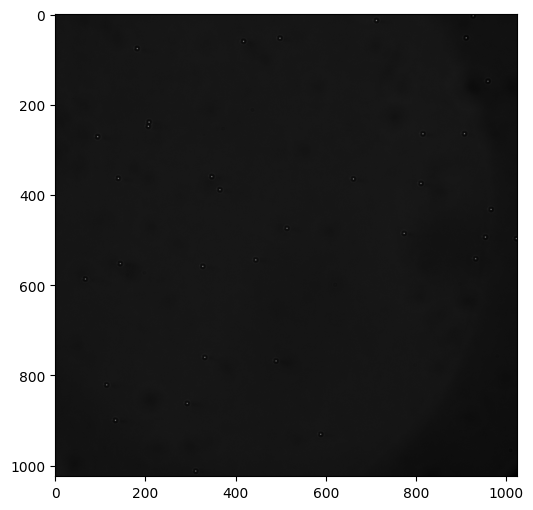

In [3]:
plt.figure(figsize = (6, 6))
plt.imshow(d, cmap="grey")
plt.show()

In [13]:
l = np.load(r"C:\Users\spraman\confocal_control_gui\napari-raman-widget\segmentation_debug\20260729_144706_615826\position_0000_labels.npy")

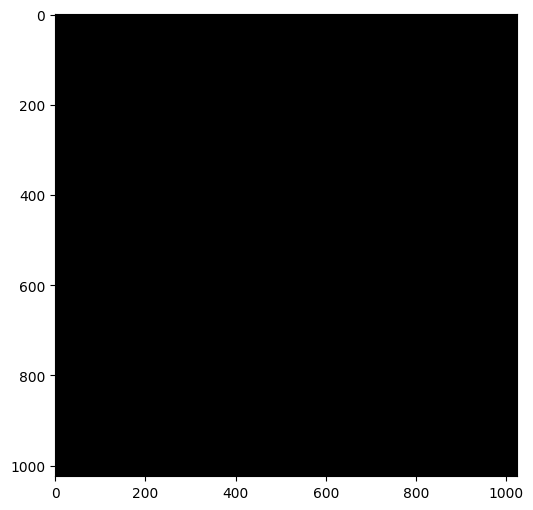

In [14]:
plt.figure(figsize = (6, 6))
plt.imshow(l, cmap="grey")
plt.show()

In [4]:
import sys

sys.path.insert(
    0,
    r"C:\Users\spraman\confocal_control_gui\raman-mda-engine",
)

from raman_mda_engine.aiming.autotracking import segment_single_img

In [7]:
mask = segment_single_img(
    d,
    scale=1,
    crop= True,
    cellpose_model="cyto2",
    circle_center=(512, 512),  # (x, y)
    circle_radius=100,
)

print("Detected labels:", int(mask.max()))

Detected labels: 2


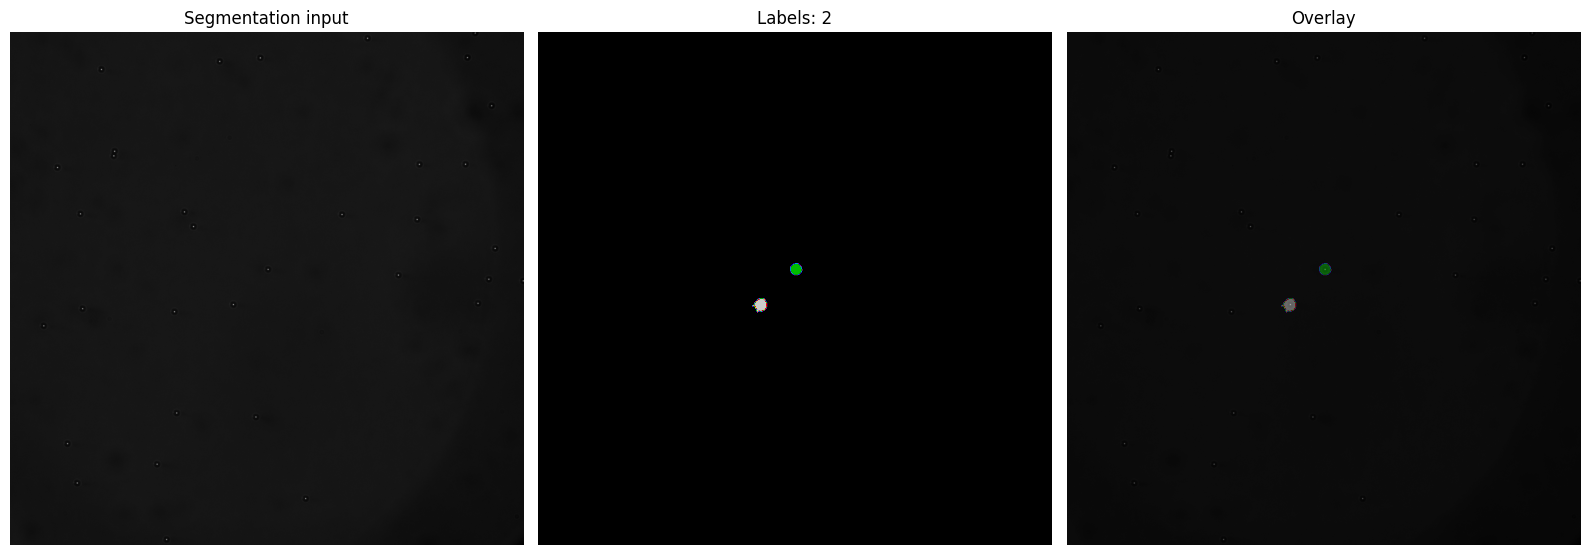

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

axes[0].imshow(d, cmap="gray")
axes[0].set_title("Segmentation input")

axes[1].imshow(mask, cmap="nipy_spectral")
axes[1].set_title(f"Labels: {int(mask.max())}")

axes[2].imshow(d, cmap="gray")
axes[2].imshow(mask, cmap="nipy_spectral", alpha=0.45)
axes[2].set_title("Overlay")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [22]:
mask_full = segment_single_img(
    d,
    scale=1,
    crop=False,
    cellpose_model="cyto2",
)

print("Cropped labels:", int(mask.max()))
print("Full-image labels:", int(mask_full.max()))

Cropped labels: 0
Full-image labels: 0
